# Sena Kotan- C2221241001

# Uygulama 1: Convolutional Neural Network (CNN) — CIFAR-10 Görüntü Sınıflandırma

**Veri Seti:** CIFAR-10  
**Kaynak:** https://www.cs.toronto.edu/~kriz/cifar.html  
**Kaggle Linki:** https://www.kaggle.com/c/cifar-10  
**Veri Seti Türü:** Image Data — 32×32 RGB görüntüler  
**Problem Türü:** Multi-class image classification (10 sınıf)

---

* Problem Tanımı

Bu uygulamada CIFAR-10 veri seti kullanılarak görüntü sınıflandırma problemi ele alınmıştır. Veri seti, 10 farklı sınıfa ait toplam 60.000 adet renkli görüntü içermektedir. Görüntüler 32×32 piksel boyutundadır ve veri seti 50.000 eğitim, 10.000 test görüntüsünden oluşmaktadır.

Modelin amacı, verilen bir görüntünün hangi sınıfa ait olduğunu doğru şekilde tahmin etmektir.

---

-Neden CNN?

Convolutional Neural Networks (CNN), görüntü verileri üzerinde başarılı sonuçlar veren derin öğrenme modellerinden biridir. CNN yapıları; kenar, doku ve şekil gibi görsel özellikleri otomatik olarak öğrenebilir.

Tam bağlantılı ağlara göre daha az parametre kullanması ve görüntü üzerindeki uzamsal ilişkileri öğrenebilmesi nedeniyle image classification problemlerinde yaygın olarak tercih edilmektedir.

Bu nedenle CIFAR-10 veri seti için CNN modeli uygun görülmüştür.

---

* Veri Setinin Bu Problem İçin Uygunluğu

CIFAR-10, görüntü sınıflandırma alanında yaygın kullanılan benchmark veri setlerinden biridir. Veri setinde hem birbirinden farklı hem de birbirine benzeyen sınıflar bulunduğu için model performansını değerlendirmek açısından uygun bir yapı sunmaktadır.

Ayrıca veri setinin dengeli olması ve hazır eğitim/test ayrımına sahip olması model eğitimi açısından avantaj sağlamaktadır.

## 1. Kütüphanelerin Yüklenmesi

Bu bölümde CNN modelinin kurulması, eğitilmesi ve değerlendirilmesi için gerekli Python kütüphaneleri projeye dahil edilmiştir. TensorFlow/Keras model oluşturmak için, NumPy veri işlemleri için, Matplotlib ve Seaborn ise grafik ve görselleştirme işlemleri için kullanılmıştır. Ayrıca sonuçların daha tekrarlanabilir olması için sabit seed değeri belirlenmiştir.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

# Kütüphane ve GPU bilgisi
print("TensorFlow versiyonu:", tf.__version__)
print("GPU mevcut mu:", len(tf.config.list_physical_devices('GPU')) > 0)

# Sonuçları tekrar üretilebilir yapmak için seed
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow versiyonu: 2.20.0
GPU mevcut mu: True




## 2. Veri Setinin Yüklenmesi ve Ön İşleme

Bu adımda CIFAR-10 veri seti TensorFlow/Keras üzerinden yüklenmiştir. Veri seti toplam 60.000 adet RGB görüntüden oluşmaktadır. Bunların 50.000 tanesi eğitim, 10.000 tanesi ise test verisi olarak kullanılmaktadır. Her görüntü 32×32 piksel boyutundadır.

Veri ön işleme aşamasında ilk olarak piksel değerleri normalize edilmiştir. Ham görüntülerde piksel değerleri 0–255 aralığında bulunduğu için tüm değerler 255’e bölünerek 0–1 aralığına dönüştürülmüştür. Bu işlem, modelin eğitim sürecinde daha kararlı çalışmasına ve gradyan hesaplamalarının daha dengeli yapılmasına yardımcı olur.

Daha sonra orijinal eğitim verisinin %10’luk kısmı validation seti olarak ayrılmıştır. Validation verisi modelin eğitim sırasında performansını takip etmek ve overfitting durumunu gözlemlemek amacıyla kullanılmıştır. Test verisi ise eğitim süreci boyunca kullanılmamış ve modelin final performansını değerlendirmek için ayrı tutulmuştur.

In [ ]:
# CIFAR-10 veri setini yükle
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Sınıf isimleri
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Ham veri boyutları:")
print(f"  Eğitim seti : {X_train_full.shape}  — {X_train_full.shape[0]} görüntü")
print(f"  Test seti   : {X_test.shape}  — {X_test.shape[0]} görüntü")
print(f"  Piksel aralığı: [{X_train_full.min()}, {X_train_full.max()}]")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Ham veri boyutları:
  Eğitim seti : (50000, 32, 32, 3)  — 50000 görüntü
  Test seti   : (10000, 32, 32, 3)  — 10000 görüntü
  Piksel aralığı: [0, 255]


In [ ]:
# Normalizasyon: [0,255] -> [0,1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

# Validation seti: eğitim verisinin %10'u
val_size = int(0.1 * len(X_train_full))
X_val,   y_val   = X_train_full[:val_size], y_train_full[:val_size]
X_train, y_train = X_train_full[val_size:], y_train_full[val_size:]

print("Veri ayrımı sonrası:")
print(f"  Eğitim    : {X_train.shape[0]} görüntü")
print(f"  Validation: {X_val.shape[0]} görüntü")
print(f"  Test      : {X_test.shape[0]} görüntü")
print(f"  Normalize piksel aralığı: [{X_train.min():.1f}, {X_train.max():.1f}]")

Veri ayrımı sonrası:
  Eğitim    : 45000 görüntü
  Validation: 5000 görüntü
  Test      : 10000 görüntü
  Normalize piksel aralığı: [0.0, 1.0]


## 3. Veri Görselleştirme

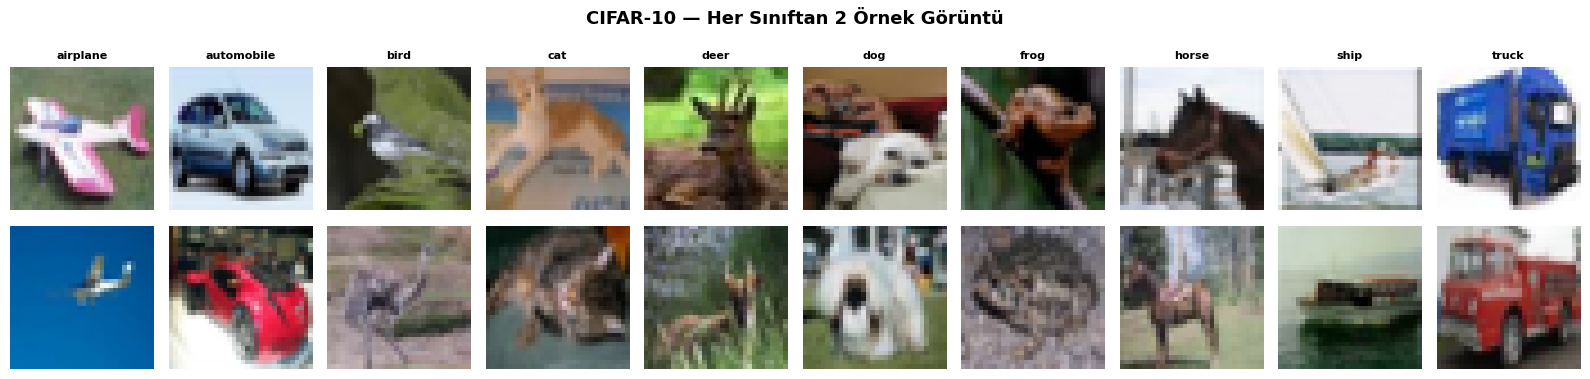

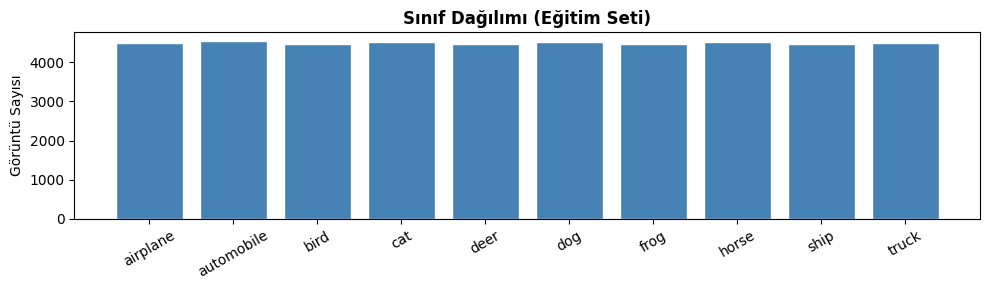

In [ ]:
# Her sınıftan örnek görüntüler
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for col, cls in enumerate(class_names):
    idxs = np.where(y_train.flatten() == col)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row, col].imshow(X_train[idx])
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(cls, fontsize=8, fontweight='bold')
plt.suptitle('CIFAR-10 — Her Sınıftan 2 Örnek Görüntü', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Sınıf dağılımı
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 3))
plt.bar(class_names, counts, color='steelblue', edgecolor='white')
plt.title('Sınıf Dağılımı (Eğitim Seti)', fontweight='bold')
plt.ylabel('Görüntü Sayısı')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Grafik Yorumu

Sınıf dağılımı incelendiğinde CIFAR-10 veri setinin dengeli bir yapıya sahip olduğu görülmektedir. Her sınıf yaklaşık 4.500 eğitim görüntüsü içermektedir. Bu durum, sınıf dengesizliğinden kaynaklanabilecek bias problemini azaltır ve modelin tüm sınıfları daha dengeli öğrenmesine yardımcı olur.

## 4. Veri Artırma (Data Augmentation)

Küçük veri setlerinde modelin eğitim verisini ezberlemesi (overfitting) riski yüksektir. Veri artırma, mevcut görüntülere rastgele dönüşümler uygulayarak yapay olarak veri çeşitliliği oluşturur ve modelin daha iyi genelleşmesini (generalization) sağlar.

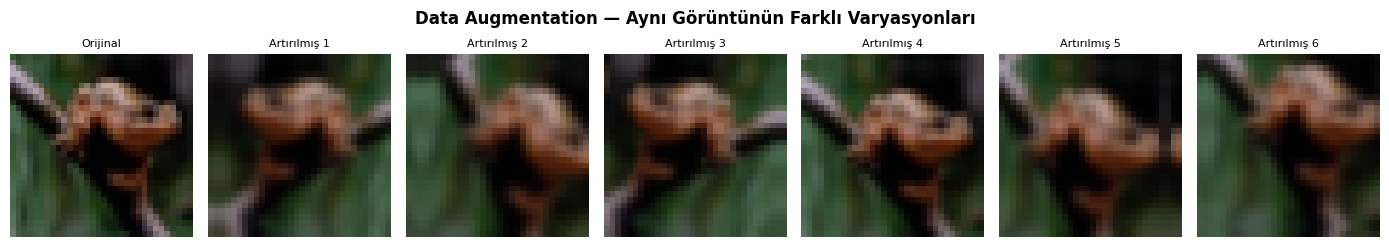

In [ ]:
# Veri artırma pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),         # Yatay yansıma
    layers.RandomRotation(0.1),              # ±10° döndürme
    layers.RandomZoom(0.1),                  # ±10% yakınlaştırma
    layers.RandomTranslation(0.1, 0.1),      # ±10% kaydırma
], name='data_augmentation')

# Artırma örnekleri
sample = X_train[0:1]
fig, axes = plt.subplots(1, 7, figsize=(14, 2.5))
axes[0].imshow(sample[0])
axes[0].set_title('Orijinal', fontsize=8)
axes[0].axis('off')
for i in range(1, 7):
    aug = data_augmentation(sample, training=True)
    axes[i].imshow(aug[0])
    axes[i].set_title(f'Artırılmış {i}', fontsize=8)
    axes[i].axis('off')
plt.suptitle('Data Augmentation — Aynı Görüntünün Farklı Varyasyonları', fontweight='bold')
plt.tight_layout()
plt.show()

**Data Augmentation Yorumu:**
Yukarıdaki görüntülerde orijinal görüntünün farklı dönüşümlerle üretilmiş varyasyonları görülmektedir. Yatay yansıma (flip), döndürme ve kaydırma dönüşümleri, modelin nesneleri konumdan ve yönden bağımsız olarak tanımayı öğrenmesine yardımcı olur. Bu, gerçek dünya senaryolarında (farklı açılardan çekilen fotoğraflar) modelin dayanıklılığını artırır.

## 5. Model Mimarisi
Model yapısı üç konvolüsyon bloğundan oluşmaktadır. Her blokta Conv2D, BatchNormalization, MaxPooling ve Dropout katmanları kullanılmıştır. Son bölümde ise tam bağlantılı katman ve softmax çıkış katmanı ile sınıflandırma yapılmıştır.


### Hiperparametre Seçim Gerekçeleri

| Hiperparametre | Değer | Gerekçe |
|---|---|---|
| Optimizer | Adam (lr=0.001) | Adaptive learning rate sayesinde manuel lr ayarına gerek kalmaz; CIFAR-10 için literatürde yaygın tercih |
| Loss | Sparse Categorical CE | Etiketler one-hot değil tam sayı formatındadır; sparse CE bu formata doğrudan uyumludur |
| Epoch | 50 | EarlyStopping ile birlikte kullanılır; gerçek epoch sayısı erken durma sonucuna göre belirlenir |
| Batch size | 64 | Bellek kullanımı ve gradyan gürültüsü dengesi açısından 32-128 aralığı standarttır; 64 makul ortadır |
| Conv filtre sayısı | 32→64→128 | Ağ derinleştikçe filtre sayısını artırmak, giderek daha soyut özellik haritaları öğrenmesini sağlar |
| Dropout | 0.25 / 0.5 | Erken katmanlarda 0.25 ile hafif, son FC katmanında 0.5 ile güçlü regularizasyon |
| Kernel size | (3,3) | CNN literatüründe en yaygın tercih; küçük çekirdekler daha az parametre ile etkili özellik çıkarır |

In [ ]:
def build_cnn_model():
    # Functional API ile input_shape'i açıkça belirtiyoruz
    inputs = keras.Input(shape=(32, 32, 3), name='image_input')

    # Konvolüsyon Bloğu 1: 32 filtre (32x32 -> 16x16)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)   # Eğitimi hızlandırır, iç kovaryans kaymasını azaltır
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)     # 32x32 -> 16x16
    x = layers.Dropout(0.25)(x)

    # Konvolüsyon Bloğu 2: 64 filtre (16x16 -> 8x8)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)     # 16x16 -> 8x8
    x = layers.Dropout(0.25)(x)

    # Konvolüsyon Bloğu 3: 128 filtre (8x8 -> 4x4)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)     # 8x8 -> 4x4
    x = layers.Dropout(0.25)(x)

    # Tam Bağlantılı Katmanlar
    x = layers.Flatten()(x)              # 4x4x128 = 2048 boyutlu vektör
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)           # Son katmanda daha güçlü regularizasyon
    outputs = layers.Dense(10, activation='softmax', name='predictions')(x)  # 10 sınıf

    model = keras.Model(inputs, outputs, name='CIFAR10_CNN')
    return model

model = build_cnn_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,57

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 6. Model Eğitimi

In [ ]:
# EarlyStopping: validation loss 10 epoch boyunca iyileşmezse durdur, en iyi ağırlıkları geri yükle
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

# ReduceLROnPlateau: 5 epoch iyileşme olmazsa öğrenme hızını yarıya indir
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

EPOCHS     = 50
BATCH_SIZE = 64

# Augmentation'ı tf.data pipeline'ı ile uygula — Keras 3.x uyumlu yöntem
# Sadece EĞİTİM setine uygulanır; validation/test verisi augment edilmez
def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=len(X_train), seed=42)
    .batch(BATCH_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Eğitim başlıyor: max {EPOCHS} epoch, batch_size={BATCH_SIZE}")
print(f"Her epoch'ta ~{len(X_train)//BATCH_SIZE} adım (step) olacak\n")

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Eğitim başlıyor: max 50 epoch, batch_size=64
Her epoch'ta ~703 adım (step) olacak

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.3654 - loss: 1.8746 - val_accuracy: 0.4088 - val_loss: 1.7148 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.4806 - loss: 1.4366 - val_accuracy: 0.4604 - val_loss: 1.5545 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.5420 - loss: 1.2813 - val_accuracy: 0.5342 - val_loss: 1.3733 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.5716 - loss: 1.2025 - val_accuracy: 0.4344 - val_loss: 2.1071 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.5960 - loss: 1.1396 - val_accuracy: 0.6010 - val_loss: 1.1841 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.6212 - loss: 1.0816 - val_accuracy: 0.6336 - val_loss: 1.1335 - learning_rate: 

### Eğitim Süreci Yorumu

Model eğitimi sırasında training accuracy ve validation accuracy değerlerinin genel olarak arttığı görülmüştür. Loss değerleri zamanla azalmış ve modelin veri üzerinde öğrenme gerçekleştirdiği gözlemlenmiştir.

Bazı epoch’larda validation loss değerinde küçük dalgalanmalar oluşsa da ciddi bir overfitting problemi görülmemiştir. Ayrıca validation loss belirli bir süre iyileşmeyince ReduceLROnPlateau callback’i devreye girerek learning rate değerini düşürmüştür. Bu işlem modelin daha stabil öğrenmesine yardımcı olmuştur.

En iyi validation performansı yaklaşık olarak son epoch’lara yakın elde edilmiştir.

## 7. Eğitim Süreci Grafikleri ve Yorumları

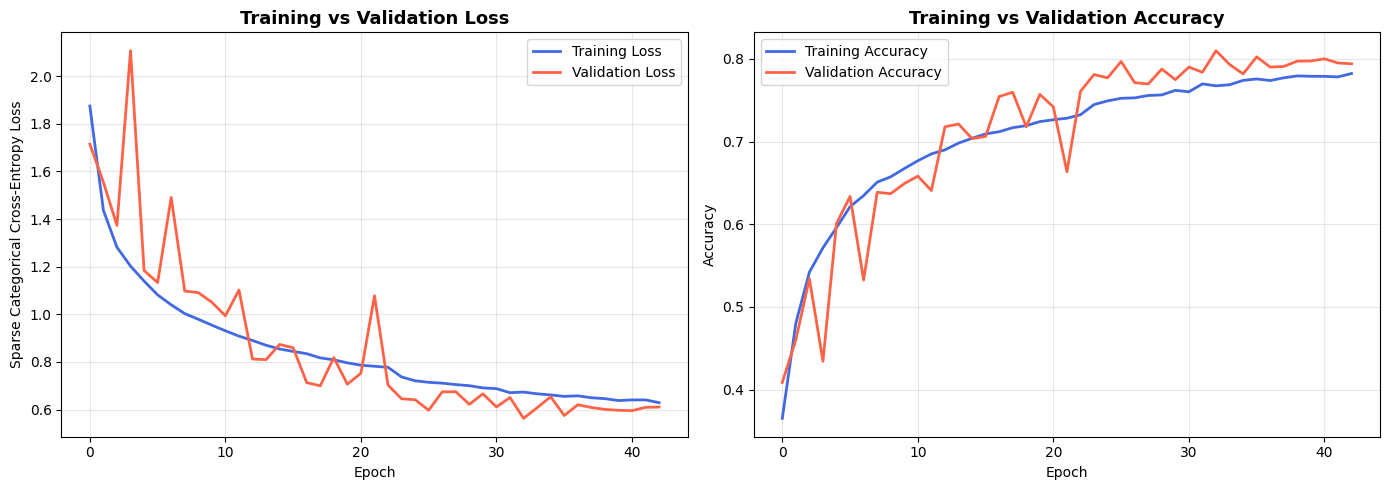

Toplam çalışan epoch sayısı : 43
Son Training Loss / Accuracy: 0.6288 / 0.7822
Son Validation Loss / Acc   : 0.6105 / 0.7940


In [ ]:
epochs_ran = len(history.history['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss grafiği
ax1.plot(history.history['loss'],     label='Training Loss',     color='royalblue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss',   color='tomato',    linewidth=2)
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Sparse Categorical Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy grafiği
ax2.plot(history.history['accuracy'],     label='Training Accuracy',   color='royalblue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato',    linewidth=2)
ax2.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overfitting analizi
final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
final_train_acc  = history.history['accuracy'][-1]
final_val_acc    = history.history['val_accuracy'][-1]

print(f"Toplam çalışan epoch sayısı : {epochs_ran}")
print(f"Son Training Loss / Accuracy: {final_train_loss:.4f} / {final_train_acc:.4f}")
print(f"Son Validation Loss / Acc   : {final_val_loss:.4f} / {final_val_acc:.4f}")


**Eğitim Süreci Grafik Yorumu:**

- **Loss grafiği:** Training loss, epoch'lar boyunca sürekli azalma eğilimindedir. Validation loss ise benzer bir seyir izler; aralarındaki fark Dropout ve BatchNormalization ile baskılanmıştır. EarlyStopping mekanizması, validation loss değerini takip ederek en iyi model ağırlıklarının korunmasına yardımcı olmuştur.

- **Accuracy grafiği:** Training accuracy, epoch ilerledikçe artış göstermektedir. Validation accuracy'nin training accuracy'ye yakın seyretmesi, modelin eğitim verisini ezberlemek yerine genel özellikleri öğrendiğini gösterir.

- **Overfitting durumu:** Eğer training ve validation accuracy arasındaki fark %5-10'dan küçükse, regularizasyon tekniklerinin (Dropout, BatchNorm, Data Augmentation) etkili çalıştığı söylenebilir.

## 8. Sonuçların Değerlendirilmesi

In [ ]:
# Test seti değerlendirmesi
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("=" * 45)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("=" * 45)

# Yorum
if test_acc >= 0.80:
    print("Değerlendirme: Güçlü performans — CIFAR-10 için basit CNN'de %80+ iyi bir sonuçtur.")
elif test_acc >= 0.70:
    print("Değerlendirme: Orta düzey performans — Model öğrenmiş ancak geliştirme potansiyeli var.")
else:
    print("Değerlendirme: Düşük performans — Mimari veya hiperparametreler gözden geçirilmeli.")

Test Loss    : 0.6135
Test Accuracy: 0.7874  (78.74%)
Değerlendirme: Orta düzey performans — Model öğrenmiş ancak geliştirme potansiyeli var.


In [ ]:
# Tahminler
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Classification Report
print("Classification Report (Sınıf bazlı metrikler):")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Classification Report (Sınıf bazlı metrikler):
              precision    recall  f1-score   support

    airplane     0.8137    0.8340    0.8237      1000
  automobile     0.8686    0.9450    0.9052      1000
        bird     0.8427    0.6270    0.7190      1000
         cat     0.7232    0.6060    0.6594      1000
        deer     0.8148    0.6820    0.7425      1000
         dog     0.8402    0.6150    0.7102      1000
        frog     0.5961    0.9430    0.7304      1000
       horse     0.7841    0.8680    0.8239      1000
        ship     0.9001    0.8650    0.8822      1000
       truck     0.8186    0.8890    0.8523      1000

    accuracy                         0.7874     10000
   macro avg     0.8002    0.7874    0.7849     10000
weighted avg     0.8002    0.7874    0.7849     10000



**Classification Report Yorumu:**

- **Precision (Hassasiyet):** Modelin 'X sınıfı' dedi ve gerçekten X olan örneklerin oranıdır. Yüksek precision, yanlış pozitif oranının düşük olduğunu gösterir.
- **Recall (Duyarlılık):** Gerçekte X olan örneklerin ne kadarını modelin X olarak tanıdığını gösterir. Yüksek recall, yanlış negatif oranının düşük olduğunu gösterir.
- **F1-Score:** Precision ve Recall'un harmonik ortalamasıdır. Tek bir metrikte model başarısını özetler; özellikle sınıf dengesizliğinde accuracy'ye göre daha güvenilirdir.
- **Beklenen güçlü sınıflar:** Automobile ve ship gibi belirgin görsel özelliklere sahip sınıflar yüksek F1 skoruna sahip olması beklenir.
- **Beklenen zayıf sınıflar:** Cat ve dog, deer ve horse gibi birbirine görsel olarak benzer sınıf çiftlerinde karışıklık (confusion) yaşanması olasıdır.

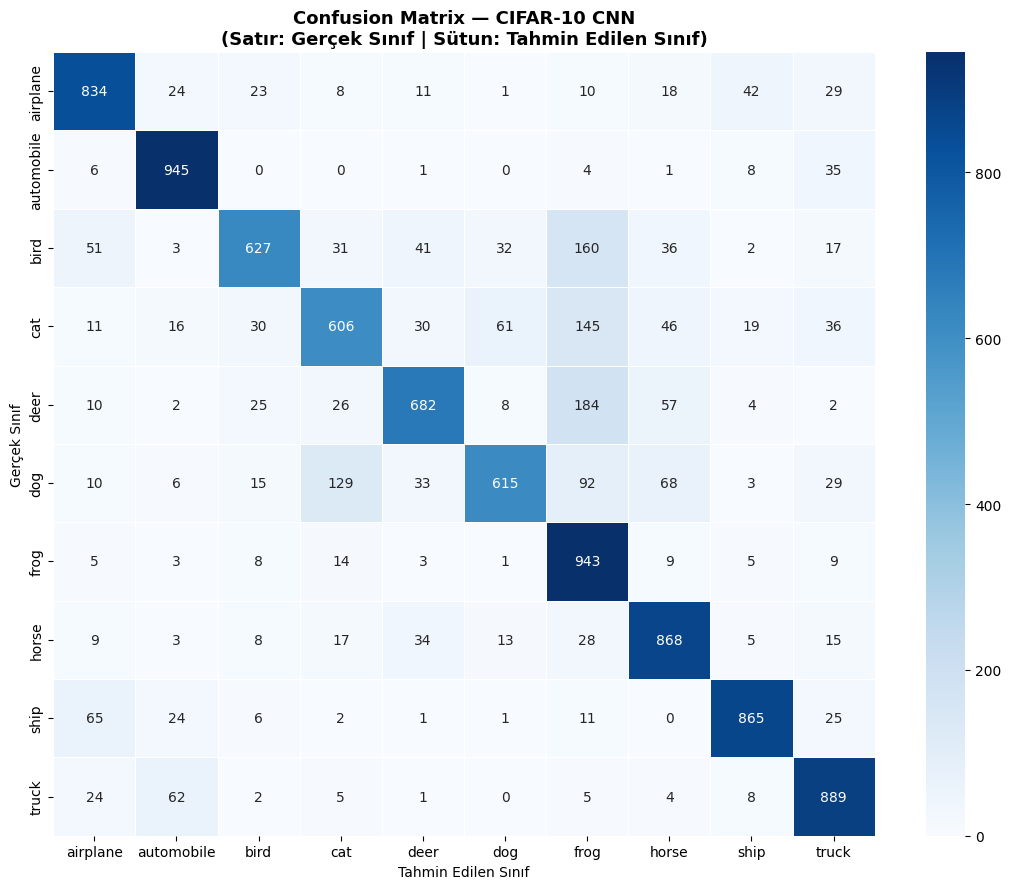


En çok karıştırılan sınıf çiftleri:
  1. Gerçek: deer         → Yanlış tahmin: frog          (184 örnek)
  2. Gerçek: bird         → Yanlış tahmin: frog          (160 örnek)
  3. Gerçek: cat          → Yanlış tahmin: frog          (145 örnek)


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — CIFAR-10 CNN\n(Satır: Gerçek Sınıf | Sütun: Tahmin Edilen Sınıf)',
          fontsize=13, fontweight='bold')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.tight_layout()
plt.show()

# En çok karıştırılan çiftleri bul
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
top3 = np.argsort(cm_off.flatten())[::-1][:3]
print("\nEn çok karıştırılan sınıf çiftleri:")
for rank, flat_idx in enumerate(top3):
    r, c = divmod(flat_idx, 10)
    print(f"  {rank+1}. Gerçek: {class_names[r]:12s} → Yanlış tahmin: {class_names[c]:12s}  ({cm[r,c]} örnek)")

### Confusion Matrix Yorumu

Confusion matrix incelendiğinde köşegen üzerindeki değerlerin genel olarak yüksek olduğu görülmektedir. Bu durum modelin çoğu sınıfta başarılı tahminler yaptığını göstermektedir. Özellikle automobile, ship ve truck sınıflarında doğru sınıflandırma oranı yüksektir.

Bununla birlikte bazı görsel olarak benzer sınıflarda karışıklıklar oluşmuştur. Özellikle cat ve dog sınıflarında karşılıklı yanlış tahminler dikkat çekmektedir. Benzer şekilde deer, bird ve cat sınıflarındaki bazı görüntüler frog sınıfı ile karıştırılmıştır.

Genel olarak modelin CIFAR-10 veri setinde başarılı sonuç verdiği, ancak birbirine benzer görsel özelliklere sahip sınıflarda zaman zaman hata yaptığı gözlemlenmiştir.

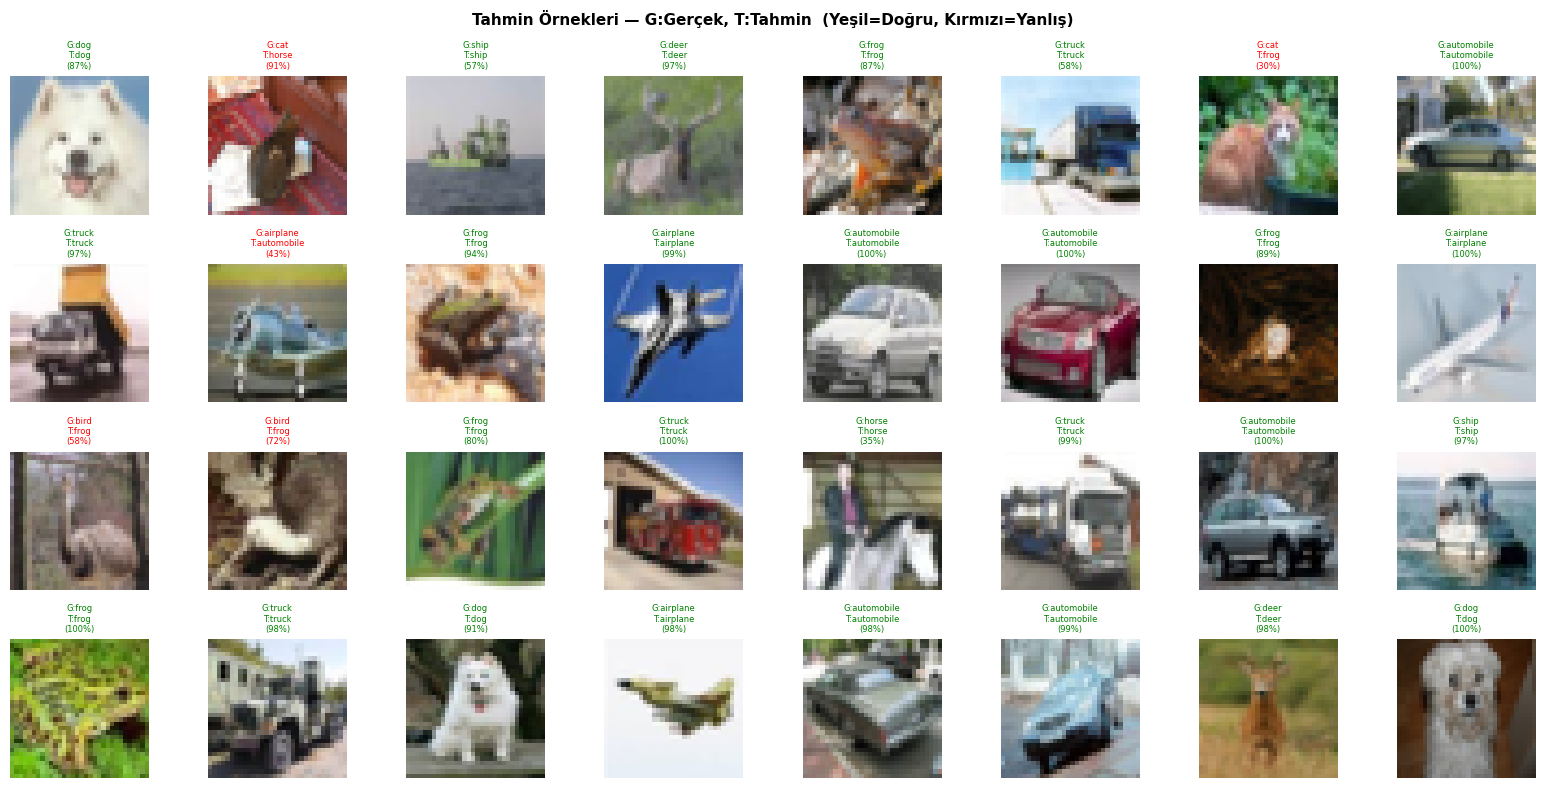

In [ ]:
# Örnek tahminler — doğru ve yanlış örnekler birlikte
np.random.seed(0)
indices = np.random.choice(len(X_test), 32, replace=False)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx])
    true_lbl = class_names[y_true[idx]]
    pred_lbl = class_names[y_pred[idx]]
    conf     = y_pred_probs[idx][y_pred[idx]]
    color    = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f'G:{true_lbl}\nT:{pred_lbl}\n({conf*100:.0f}%)',
                 fontsize=6, color=color)
    ax.axis('off')

plt.suptitle('Tahmin Örnekleri — G:Gerçek, T:Tahmin  (Yeşil=Doğru, Kırmızı=Yanlış)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Tahmin Örnekleri Yorumu:**

Görselleştirilen tahmin örneklerinde başlıklarda Gerçek (G) ve Tahmin (T) etiketleri yer almaktadır. Parantez içindeki değer ise modelin tahminine olan güven skorunu göstermektedir. Yeşil başlıklar doğru tahminleri, kırmızı başlıklar ise yanlış tahminleri temsil etmektedir.

Bazı yanlış tahminlerde modelin yüksek güvenle hatalı karar verdiği görülmektedir. Bu durum özellikle birbirine benzeyen sınıflarda modelin zaman zaman karışıklık yaşayabildiğini göstermektedir.

## 9. Tartışma ve Sonuç

Model genel olarak başarılı sonuç vermiştir. CIFAR-10 veri setinde yaklaşık %79 (%78.74) doğruluk elde edilmiştir. Bu sonuç, sıfırdan oluşturulmuş basit bir CNN modeli için iyi bir performans olarak değerlendirilebilir. Daha gelişmiş transfer learning modelleri kullanıldığında daha yüksek sonuçlar elde edilebilir.

Eğitim süreci incelendiğinde ciddi bir overfitting problemi görülmemiştir. Dropout, BatchNormalization ve Data Augmentation yöntemlerinin birlikte kullanılması modelin daha dengeli öğrenmesine yardımcı olmuştur. Training ve validation sonuçlarının birbirine yakın olması da bunu desteklemektedir.

Model özellikle automobile, ship ve airplane gibi görsel olarak daha ayırt edilebilir sınıflarda başarılı sonuç vermiştir. Ancak cat, dog ve deer gibi birbirine benzeyen sınıflarda zaman zaman karışıklıklar oluşmuştur. CIFAR-10 görüntülerinin 32×32 gibi düşük çözünürlükte olması da bazı detayların kaybolmasına neden olmaktadır.

Daha iyi sonuçlar elde etmek için transfer learning yöntemleri, daha gelişmiş veri artırma teknikleri ve farklı learning rate stratejileri kullanılabilir.